# Python for Business Intelligence - Project

## AI Statement

Artificial intelligence was used as a supporting tool during this project. It helped with organizing the notebook structure and checking that the workflow followed a somewhat logical order. It was also used for some code guidance when adapting the analysis to the Global Superstore dataset as I had to change datasets after already starting on my original idea due to missing data on all holidays.

The main project decisions, including the dataset selection, country filtering, holiday filtering, analysis approach, interpretation of results, and final conclusions, were done by myself. AI was used to support the work process when I got stuck or needed a push in the right direction when not sure of specific pieces of code.

## How can you run this notebook yourself?

This notebook analyzes whether public holidays are associated with changes in online retail sales across countries.

To run the notebook:

1. Place `superstore.csv` which can be obtained from https://www.kaggle.com/datasets/fatihilhan/global-superstore-dataset in the same folder as this notebook.
2. Create a `.env` file in the same folder.
3. Add the Calendarific API key to the `.env` file using the following code:

CALENDARIFIC_API_KEY=your_api_key_here

4. Make sure `.env` is included in `.gitignore`.
5. Run the notebook from top to bottom.

The notebook first loads the online retail dataset, then collects public holiday data from the Calendarific API, cleans and transforms the data, and finally analyzes daily sales patterns around holidays.

## Pipeline image

![Project pipeline](projectpipeline.png)

## 1. Introduction and Project Objective

This project analyzes whether national holidays are associated with changes in online retail sales. The analysis combines transaction-level data from the Global Superstore dataset with external holiday data collected from the Calendarific API.

The main research question is:

**How are national holidays and the days around national holidays associated with online retail sales in selected European countries and the United States?**

The analysis focuses on daily sales, number of orders, units sold, profit, and average order value. The purpose is not to prove a fully causal holiday effect, but to identify patterns that may be useful for business intelligence, sales monitoring, and future demand planning.

## 2. Data Loading and Initial Inspection

The first step is to load the Superstore dataset and inspect its basic structure. This includes checking the number of rows and columns, reviewing column names, converting date variables, and checking for missing values.

The raw dataset contains 51,290 rows and 27 columns. Each row represents an order line, meaning that one order may appear on several rows if it contains multiple products. The most important variables for this project are country, order date, order ID, sales, profit, quantity, customer ID, and product ID.

The date range is from 2011 to 2014, which determines the years for which holiday data must be collected from the Calendarific API.

In [1]:
import os
import time
from pathlib import Path

import pandas as pd
import numpy as np
import requests
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [2]:
if Path.cwd().name != "Project":
    os.chdir("Project")

retail = pd.read_csv("superstore.csv", encoding="latin1")

print("Rows and columns:")
print(retail.shape)

print("\nColumn names:")
print(retail.columns.tolist())

display(retail.head())

Rows and columns:
(51290, 27)

Column names:
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'è®°å½\x95æ\x95°', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


## 3. Data Cleaning and Country Selection

The column names are cleaned by converting them to lower-case and replacing dots and spaces with underscores. This makes the variables easier to use in Python. The date variables are converted into datetime format, and numeric variables such as sales, profit, quantity, discount, and shipping cost are converted into numeric format.

After this, the dataset is filtered to keep only valid sales rows. Since the Superstore dataset is already clean, no rows are removed in this step.

Because the analysis is based on daily country-level sales, countries with very little data are excluded. A country must have at least 100 transaction rows and at least 50 distinct sales days. This avoids drawing conclusions from countries where the results could be driven by only a few transactions.

After applying this rule, 61 countries fulfill both requirements. To keep the project focused and to stay within practical API limits, the final sample is limited to Europe and the United States. This leaves 16 countries and 22,276 transaction rows for the main analysis.

In [3]:
retail_clean = retail.copy()

retail_clean.columns = (
    retail_clean.columns
    .str.strip()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.lower()
)

# Rename possible corrupted record-count column if it exists
for col in retail_clean.columns:
    if "å" in col or "®" in col or "½" in col:
        retail_clean = retail_clean.rename(columns={col: "record_count"})

print(retail_clean.columns.tolist())
display(retail_clean.head())

['category', 'city', 'country', 'customer_id', 'customer_name', 'discount', 'market', 'record_count', 'order_date', 'order_id', 'order_priority', 'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state', 'sub_category', 'year', 'market2', 'weeknum']


,category,city,country,customer_id,customer_name,discount,market,record_count,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,row_id,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
required_cols = [
    "country",
    "order_date",
    "ship_date",
    "sales",
    "profit",
    "quantity",
    "order_id",
    "customer_id",
    "product_id",
    "row_id"
]

missing_required = [col for col in required_cols if col not in retail_clean.columns]

if missing_required:
    print("Missing required columns:")
    print(missing_required)
else:
    print("All required columns found.")

All required columns found.


In [5]:
retail_clean["order_date"] = pd.to_datetime(retail_clean["order_date"], errors="coerce")
retail_clean["ship_date"] = pd.to_datetime(retail_clean["ship_date"], errors="coerce")

numeric_cols = ["sales", "profit", "quantity", "discount", "shipping_cost"]

for col in numeric_cols:
    if col in retail_clean.columns:
        retail_clean[col] = pd.to_numeric(retail_clean[col], errors="coerce")

retail_clean["date"] = retail_clean["order_date"].dt.date
retail_clean["year"] = retail_clean["order_date"].dt.year
retail_clean["month"] = retail_clean["order_date"].dt.month
retail_clean["weekday"] = retail_clean["order_date"].dt.day_name()

display(retail_clean.head())

,category,city,country,customer_id,customer_name,discount,market,record_count,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,row_id,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum,date,month,weekday
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2,2011-01-07,1,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4,2011-01-21,1,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32,2011-08-05,8,Friday
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32,2011-08-05,8,Friday
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40,2011-09-29,9,Thursday


In [6]:
print("Dataset information:")
retail_clean.info()

print("\nDate range:")
print(retail_clean["order_date"].min(), "to", retail_clean["order_date"].max())

print("\nYears in the dataset:")
print(sorted(retail_clean["year"].dropna().astype(int).unique()))

missing_values = (
    retail_clean.isna()
    .sum()
    .reset_index()
)

missing_values.columns = ["column", "missing_values"]
missing_values["missing_percent"] = missing_values["missing_values"] / len(retail_clean) * 100

display(missing_values.sort_values("missing_values", ascending=False))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   category        51290 non-null  object        
 1   city            51290 non-null  object        
 2   country         51290 non-null  object        
 3   customer_id     51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   discount        51290 non-null  float64       
 6   market          51290 non-null  object        
 7   record_count    51290 non-null  int64         
 8   order_date      51290 non-null  datetime64[ns]
 9   order_id        51290 non-null  object        
 10  order_priority  51290 non-null  object        
 11  product_id      51290 non-null  object        
 12  product_name    51290 non-null  object        
 13  profit          51290 non-null  float64       
 14  quantity        51290 non-null  i

,column,missing_values,missing_percent
0,category,0,0.0
1,city,0,0.0
2,country,0,0.0
3,customer_id,0,0.0
4,customer_name,0,0.0
5,discount,0,0.0
6,market,0,0.0
7,record_count,0,0.0
8,order_date,0,0.0
9,order_id,0,0.0


In [7]:
print("Rows before cleaning:", len(retail_clean))

sales_clean = retail_clean[
    retail_clean["country"].notna() &
    retail_clean["order_date"].notna() &
    retail_clean["sales"].notna() &
    retail_clean["quantity"].notna() &
    (retail_clean["sales"] >= 0) &
    (retail_clean["quantity"] > 0)
].copy()

print("Rows after cleaning:", len(sales_clean))
print("Rows removed:", len(retail_clean) - len(sales_clean))

display(sales_clean.head())

Rows before cleaning: 51290
Rows after cleaning: 51290
Rows removed: 0


,category,city,country,customer_id,customer_name,discount,market,record_count,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,row_id,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum,date,month,weekday
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2,2011-01-07,1,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4,2011-01-21,1,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32,2011-08-05,8,Friday
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32,2011-08-05,8,Friday
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40,2011-09-29,9,Thursday


In [8]:
country_coverage = (
    sales_clean
    .groupby("country")
    .agg(
        number_of_rows=("country", "size"),
        distinct_sales_days=("date", "nunique"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_sales=("sales", "sum")
    )
    .sort_values(["number_of_rows", "distinct_sales_days"], ascending=False)
    .reset_index()
)

display(country_coverage)

,country,number_of_rows,distinct_sales_days,first_order_date,last_order_date,total_sales
0,United States,9994,1238,2011-01-04,2014-12-31,2297354
1,Australia,2837,786,2011-01-01,2014-12-30,925257
2,France,2827,789,2011-01-04,2014-12-31,858930
3,Mexico,2644,771,2011-01-04,2014-12-31,622620
4,Germany,2065,652,2011-01-12,2014-12-31,628857
...,...,...,...,...,...,...
142,South Sudan,2,2,2011-04-20,2014-12-31,1045
143,Swaziland,2,2,2011-11-16,2014-03-18,288
144,Bahrain,2,1,2013-09-20,2013-09-20,669
145,Chad,2,1,2013-02-14,2013-02-14,1317


Next we filter out countries with too little data:

In [9]:
eligible_countries = country_coverage[
    (country_coverage["number_of_rows"] >= 100) &
    (country_coverage["distinct_sales_days"] >= 50)
].copy()

print("Countries fulfilling both requirements:", eligible_countries["country"].nunique())
display(eligible_countries)

Countries fulfilling both requirements: 61


,country,number_of_rows,distinct_sales_days,first_order_date,last_order_date,total_sales
0,United States,9994,1238,2011-01-04,2014-12-31,2297354
1,Australia,2837,786,2011-01-01,2014-12-30,925257
2,France,2827,789,2011-01-04,2014-12-31,858930
3,Mexico,2644,771,2011-01-04,2014-12-31,622620
4,Germany,2065,652,2011-01-12,2014-12-31,628857
...,...,...,...,...,...,...
56,Senegal,112,55,2011-02-14,2014-12-20,28850
57,Cameroon,110,65,2011-03-07,2014-12-29,22355
59,Ireland,106,50,2011-02-22,2014-12-29,16638
62,Ghana,102,57,2011-05-18,2014-12-05,23272


To stay witin limits of my API limit we will keep only Europe and the US

In [10]:
europe_us_countries = [
    "United States",
    "France",
    "Germany",
    "United Kingdom",
    "Turkey",
    "Italy",
    "Spain",
    "Netherlands",
    "Russia",
    "Ukraine",
    "Austria",
    "Poland",
    "Sweden",
    "Romania",
    "Belgium",
    "Ireland"
]

sales_filtered = sales_clean[
    sales_clean["country"].isin(europe_us_countries)
].copy()

final_country_coverage = country_coverage[
    country_coverage["country"].isin(europe_us_countries)
].copy()

final_country_coverage = final_country_coverage.sort_values("number_of_rows", ascending=False)

print("Final number of countries:", sales_filtered["country"].nunique())
print("Final number of rows:", len(sales_filtered))

display(final_country_coverage)

Final number of countries: 16
Final number of rows: 22276


,country,number_of_rows,distinct_sales_days,first_order_date,last_order_date,total_sales
0,United States,9994,1238,2011-01-04,2014-12-31,2297354
2,France,2827,789,2011-01-04,2014-12-31,858930
4,Germany,2065,652,2011-01-12,2014-12-31,628857
6,United Kingdom,1633,604,2011-01-03,2014-12-31,528570
10,Turkey,1378,494,2011-01-11,2014-12-31,108524
11,Italy,1108,437,2011-01-11,2014-12-30,289717
13,Spain,859,366,2011-01-11,2014-12-31,287162
26,Netherlands,435,192,2011-01-07,2014-12-31,77520
31,Russia,384,173,2011-01-20,2014-12-31,82915
32,Ukraine,381,194,2011-03-01,2014-12-31,86855


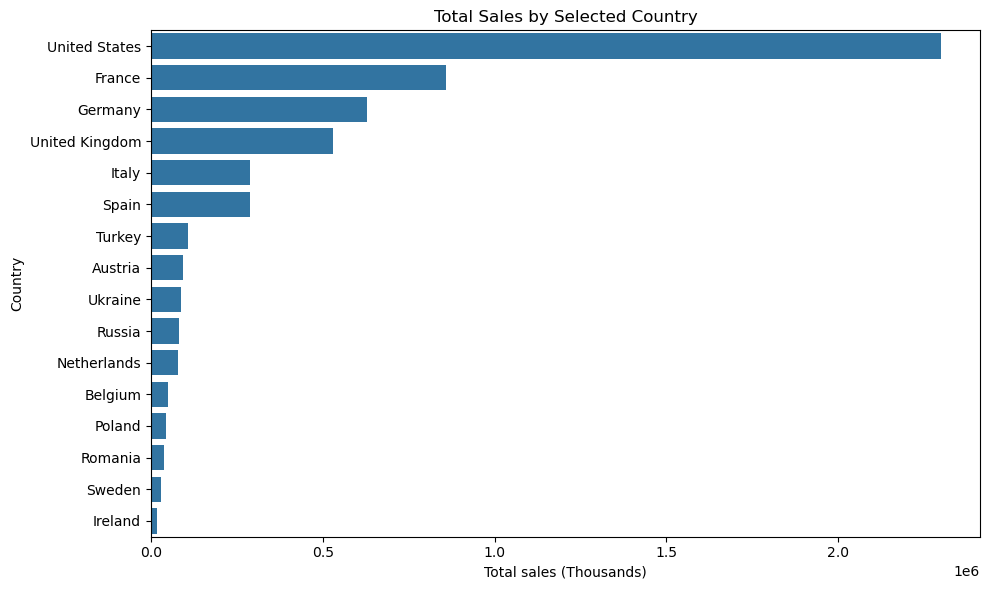

In [11]:
country_sales_plot = (
    sales_filtered
    .groupby("country", as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_sales_plot,
    x="total_sales",
    y="country"
)

plt.title("Total Sales by Selected Country")
plt.xlabel("Total sales (Thousands)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 4. Holiday Data Collection from Calendarific API

In this project I use the Calendarific API to collect national holiday data for the selected countries and years. Since the Superstore data covers 2011–2014, the API requests are made for each selected country and each year in this period.

A country-code mapping is needed because the API uses two-letter country codes, such as US for the United States, FR for France, and DE for Germany. In total, the project requires 64 API requests: 16 countries multiplied by 4 years.

The raw API data is saved to a CSV file. This is useful because it avoids calling the API again every time the notebook is restarted.

In [12]:
load_dotenv()

api_key = os.getenv("CALENDARIFIC_API_KEY")

if api_key is None:
    print("API key not found. Add CALENDARIFIC_API_KEY to your .env file.")
else:
    print("API key loaded successfully.")

API key loaded successfully.


Next we extract the Holiday data:

In [13]:
country_code_map = {
    "United States": "US",
    "France": "FR",
    "Germany": "DE",
    "United Kingdom": "GB",
    "Turkey": "TR",
    "Italy": "IT",
    "Spain": "ES",
    "Netherlands": "NL",
    "Russia": "RU",
    "Ukraine": "UA",
    "Austria": "AT",
    "Poland": "PL",
    "Sweden": "SE",
    "Romania": "RO",
    "Belgium": "BE",
    "Ireland": "IE"
}

years = sorted(sales_filtered["order_date"].dt.year.dropna().astype(int).unique())

print("Countries used for API calls:")
print(list(country_code_map.keys()))

print("\nYears used for API calls:")
print(years)

print("\nNumber of API requests needed:")
print(len(country_code_map) * len(years))

Countries used for API calls:
['United States', 'France', 'Germany', 'United Kingdom', 'Turkey', 'Italy', 'Spain', 'Netherlands', 'Russia', 'Ukraine', 'Austria', 'Poland', 'Sweden', 'Romania', 'Belgium', 'Ireland']

Years used for API calls:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]

Number of API requests needed:
64


In [14]:
def fetch_holidays(country_name, country_code, year):
    url = "https://calendarific.com/api/v2/holidays"
    
    params = {
        "api_key": api_key,
        "country": country_code,
        "year": int(year),
        "type": "national"
    }
    
    response = requests.get(url, params=params, timeout=30)
    
    if response.status_code != 200:
        print(f"Request failed for {country_name} {year}: {response.status_code}")
        print(response.text[:300])
        return []
    
    data = response.json()
    
    if data.get("meta", {}).get("code") != 200:
        print(f"API error for {country_name} {year}:")
        print(data)
        return []
    
    holiday_rows = []
    
    for holiday in data.get("response", {}).get("holidays", []):
        holiday_rows.append({
            "country": country_name,
            "country_code": country_code,
            "year": int(year),
            "holiday_name": holiday.get("name"),
            "holiday_date": holiday.get("date", {}).get("iso"),
            "holiday_type": ", ".join(holiday.get("type", [])) if isinstance(holiday.get("type"), list) else holiday.get("type"),
            "source": "Calendarific"
        })
    
    return holiday_rows

In [15]:
holiday_cache_file = Path("raw_holidays_calendarific_superstore.csv")

if holiday_cache_file.exists():
    holidays_df = pd.read_csv(holiday_cache_file)
    print("Loaded cached holiday data from:", holiday_cache_file)
else:
    if api_key is None:
        raise ValueError("No API key found. Add CALENDARIFIC_API_KEY=your_key_here to your .env file.")
    
    all_holidays = []
    
    for country_name, country_code in country_code_map.items():
        for year in years:
            print(f"Fetching holidays for {country_name} ({country_code}) in {year}")
            
            holiday_rows = fetch_holidays(
                country_name=country_name,
                country_code=country_code,
                year=year
            )
            
            all_holidays.extend(holiday_rows)
            time.sleep(0.25)
    
    holidays_df = pd.DataFrame(all_holidays)
    holidays_df.to_csv(holiday_cache_file, index=False)
    print("Raw holiday data exported to:", holiday_cache_file)

holidays_df["holiday_date"] = pd.to_datetime(
    holidays_df["holiday_date"],
    errors="coerce",
    format="mixed"
).dt.date

display(holidays_df.head())
print("Number of holiday rows:", len(holidays_df))

Fetching holidays for United States (US) in 2011
Fetching holidays for United States (US) in 2012
Fetching holidays for United States (US) in 2013
Fetching holidays for United States (US) in 2014
Fetching holidays for France (FR) in 2011
Fetching holidays for France (FR) in 2012
Fetching holidays for France (FR) in 2013
Fetching holidays for France (FR) in 2014
Fetching holidays for Germany (DE) in 2011
Fetching holidays for Germany (DE) in 2012
Fetching holidays for Germany (DE) in 2013
Fetching holidays for Germany (DE) in 2014
Fetching holidays for United Kingdom (GB) in 2011
Fetching holidays for United Kingdom (GB) in 2012
Fetching holidays for United Kingdom (GB) in 2013
Fetching holidays for United Kingdom (GB) in 2014
Fetching holidays for Turkey (TR) in 2011
Fetching holidays for Turkey (TR) in 2012
Fetching holidays for Turkey (TR) in 2013
Fetching holidays for Turkey (TR) in 2014
Fetching holidays for Italy (IT) in 2011
Fetching holidays for Italy (IT) in 2012
Fetching holid

,country,country_code,year,holiday_name,holiday_date,holiday_type,source
0,United States,US,2011,New Year's Day,2011-01-01,National holiday,Calendarific
1,United States,US,2011,Martin Luther King Jr. Day,2011-01-17,National holiday,Calendarific
2,United States,US,2011,Presidents' Day,2011-02-21,National holiday,Calendarific
3,United States,US,2011,Memorial Day,2011-05-30,National holiday,Calendarific
4,United States,US,2011,Independence Day,2011-07-04,National holiday,Calendarific


Number of holiday rows: 755


In [16]:
holidays_clean = holidays_df.copy()

holidays_clean["holiday_date"] = pd.to_datetime(
    holidays_clean["holiday_date"],
    errors="coerce"
).dt.date

holidays_clean = holidays_clean.dropna(subset=["country", "holiday_date"])

holidays_clean = holidays_clean[
    holidays_clean["country"].isin(europe_us_countries) &
    (pd.to_datetime(holidays_clean["holiday_date"]).dt.year.isin(years))
].copy()

print("Rows after holiday cleaning:", len(holidays_clean))
display(holidays_clean.head())

Rows after holiday cleaning: 755


,country,country_code,year,holiday_name,holiday_date,holiday_type,source
0,United States,US,2011,New Year's Day,2011-01-01,National holiday,Calendarific
1,United States,US,2011,Martin Luther King Jr. Day,2011-01-17,National holiday,Calendarific
2,United States,US,2011,Presidents' Day,2011-02-21,National holiday,Calendarific
3,United States,US,2011,Memorial Day,2011-05-30,National holiday,Calendarific
4,United States,US,2011,Independence Day,2011-07-04,National holiday,Calendarific


In [17]:
holidays_clean = holidays_clean[
    holidays_clean["holiday_type"].str.strip().eq("National holiday")
].copy()

national_holidays_clean = (
    holidays_clean
    .groupby(["country", "country_code", "holiday_date"])
    .agg(
        holiday_names=("holiday_name", lambda x: "; ".join(sorted(set(x.dropna())))),
        holiday_types=("holiday_type", lambda x: "; ".join(sorted(set(x.dropna()))))
    )
    .reset_index()
)

display(national_holidays_clean.head())
print("Rows after removing duplicate country-date holidays:", len(national_holidays_clean))

,country,country_code,holiday_date,holiday_names,holiday_types
0,Austria,AT,2011-01-01,New Year's Day,National holiday
1,Austria,AT,2011-01-06,Epiphany,National holiday
2,Austria,AT,2011-04-25,Easter Monday,National holiday
3,Austria,AT,2011-05-01,Labor Day / May Day,National holiday
4,Austria,AT,2011-06-02,Ascension Day,National holiday


Rows after removing duplicate country-date holidays: 670


In [18]:
holidays_clean_counts = (
    holidays_clean
    .groupby("country")
    .agg(number_of_national_holiday_dates=("holiday_date", "nunique"))
    .sort_values("number_of_national_holiday_dates", ascending=False)
    .reset_index()
)

display(holidays_clean_counts)

,country,number_of_national_holiday_dates
0,Russia,69
1,Austria,52
2,Sweden,52
3,Poland,52
4,Turkey,51
5,Italy,48
6,Netherlands,44
7,France,44
8,Spain,43
9,Belgium,40


Only holidays where the Calendarific holiday type is exactly `National holiday` are kept. This removes holidays classified as for example observance, or other non-national holiday types.

## 5. Creating the Daily Sales and Holiday Dataset

The transaction-level Superstore data is aggregated to country-date level because the holiday data is also defined by country and date. For each country and date, I calculates total daily sales, daily profit, number of orders, units sold, number of unique customers, number of unique products, and average order value.

A complete daily panel is then created for each country. This means that dates without transactions are kept in the dataset and assigned sales of zero. This is important because holiday dates with no sales should not disappear from the analysis.

The cleaned holiday data is merged with the daily sales data using country and date. The variable `is_holiday` identifies whether a country-date is a national holiday.

I also create three-day holiday-window variables. `pre_holiday_3days` identifies the three days before a national holiday, while `post_holiday_3days` identifies the three days after a national holiday. This makes it possible to test whether sales change not only on the holiday itself, but also around the holiday.

In [19]:
daily_sales = (
    sales_filtered
    .groupby(["country", "date"])
    .agg(
        daily_sales=("sales", "sum"),
        daily_profit=("profit", "sum"),
        number_of_orders=("order_id", "nunique"),
        units_sold=("quantity", "sum"),
        unique_customers=("customer_id", "nunique"),
        unique_products=("product_id", "nunique"),
        number_of_rows=("row_id", "count")
    )
    .reset_index()
)

daily_sales["average_order_value"] = (
    daily_sales["daily_sales"] / daily_sales["number_of_orders"]
)

display(daily_sales.head())
print("Rows in daily sales data:", len(daily_sales))

,country,date,daily_sales,daily_profit,number_of_orders,units_sold,unique_customers,unique_products,number_of_rows,average_order_value
0,Austria,2011-01-11,152,40.89,1,3,1,2,2,152.0
1,Austria,2011-01-14,1150,246.51,1,20,1,3,3,1150.0
2,Austria,2011-03-28,542,17.28,1,7,1,3,3,542.0
3,Austria,2011-04-20,110,12.09,1,1,1,1,1,110.0
4,Austria,2011-05-05,1532,603.69,2,8,2,4,4,766.0


Rows in daily sales data: 5727


In [20]:
country_ranges = (
    sales_filtered
    .groupby("country")
    .agg(
        first_date=("order_date", "min"),
        last_date=("order_date", "max")
    )
    .reset_index()
)

calendar_rows = []

for _, row in country_ranges.iterrows():
    dates = pd.date_range(row["first_date"], row["last_date"], freq="D")
    temp = pd.DataFrame({
        "country": row["country"],
        "date": dates.date
    })
    calendar_rows.append(temp)

calendar_panel = pd.concat(calendar_rows, ignore_index=True)

daily = calendar_panel.merge(
    daily_sales,
    on=["country", "date"],
    how="left"
)

zero_fill_cols = [
    "daily_sales",
    "daily_profit",
    "number_of_orders",
    "units_sold",
    "unique_customers",
    "unique_products",
    "number_of_rows",
    "average_order_value"
]

for col in zero_fill_cols:
    daily[col] = daily[col].fillna(0)

display(daily.head())
print("Rows in complete daily panel:", len(daily))

,country,date,daily_sales,daily_profit,number_of_orders,units_sold,unique_customers,unique_products,number_of_rows,average_order_value
0,Austria,2011-01-11,152.0,40.89,1.0,3.0,1.0,2.0,2.0,152.0
1,Austria,2011-01-12,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2,Austria,2011-01-13,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,Austria,2011-01-14,1150.0,246.51,1.0,20.0,1.0,3.0,3.0,1150.0
4,Austria,2011-01-15,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0


Rows in complete daily panel: 23023


In [21]:
national_holidays_clean = national_holidays_clean.rename(
    columns={"holiday_date": "date"}
)

national_holidays_clean["date"] = pd.to_datetime(
    national_holidays_clean["date"]
).dt.date

daily = daily.merge(
    national_holidays_clean,
    on=["country", "date"],
    how="left"
)

daily["is_holiday"] = daily["holiday_names"].notna().astype(int)
daily["holiday_names"] = daily["holiday_names"].fillna("")
daily["holiday_types"] = daily["holiday_types"].fillna("")

display(daily.head())

,country,date,daily_sales,daily_profit,number_of_orders,units_sold,unique_customers,unique_products,number_of_rows,average_order_value,country_code,holiday_names,holiday_types,is_holiday
0,Austria,2011-01-11,152.0,40.89,1.0,3.0,1.0,2.0,2.0,152.0,NaN,,,0
1,Austria,2011-01-12,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0
2,Austria,2011-01-13,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0
3,Austria,2011-01-14,1150.0,246.51,1.0,20.0,1.0,3.0,3.0,1150.0,NaN,,,0
4,Austria,2011-01-15,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0


In [22]:
daily["pre_holiday_3days"] = 0
daily["post_holiday_3days"] = 0

for country in daily["country"].unique():
    country_mask = daily["country"] == country
    
    holiday_dates = set(
        daily.loc[
            country_mask & (daily["is_holiday"] == 1),
            "date"
        ]
    )
    
    daily.loc[country_mask, "pre_holiday_3days"] = daily.loc[
        country_mask, "date"
    ].apply(
        lambda d: int(any(0 < (pd.to_datetime(h) - pd.to_datetime(d)).days <= 3 for h in holiday_dates))
    )
    
    daily.loc[country_mask, "post_holiday_3days"] = daily.loc[
        country_mask, "date"
    ].apply(
        lambda d: int(any(0 < (pd.to_datetime(d) - pd.to_datetime(h)).days <= 3 for h in holiday_dates))
    )

daily["holiday_window"] = np.select(
    [
        daily["is_holiday"].eq(1),
        daily["pre_holiday_3days"].eq(1),
        daily["post_holiday_3days"].eq(1)
    ],
    [
        "Holiday",
        "Pre-holiday",
        "Post-holiday"
    ],
    default="Normal"
)

display(daily.head())
display(daily["holiday_window"].value_counts())

,country,date,daily_sales,daily_profit,number_of_orders,units_sold,unique_customers,unique_products,number_of_rows,average_order_value,country_code,holiday_names,holiday_types,is_holiday,pre_holiday_3days,post_holiday_3days,holiday_window
0,Austria,2011-01-11,152.0,40.89,1.0,3.0,1.0,2.0,2.0,152.0,NaN,,,0,0,0,Normal
1,Austria,2011-01-12,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal
2,Austria,2011-01-13,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal
3,Austria,2011-01-14,1150.0,246.51,1.0,20.0,1.0,3.0,3.0,1150.0,NaN,,,0,0,0,Normal
4,Austria,2011-01-15,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal


holiday_window
Normal          19495
Pre-holiday      1505
Post-holiday     1380
Holiday           643
Name: count, dtype: int64

In [23]:
daily["date"] = pd.to_datetime(daily["date"])
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["weekday"] = daily["date"].dt.day_name()
daily["weekday_number"] = daily["date"].dt.dayofweek
daily["is_weekend"] = daily["weekday_number"].isin([5, 6]).astype(int)

daily["has_sales"] = (daily["daily_sales"] > 0).astype(int)
daily["log_daily_sales"] = np.log1p(daily["daily_sales"])

display(daily.head())

,country,date,daily_sales,daily_profit,number_of_orders,units_sold,unique_customers,unique_products,number_of_rows,average_order_value,country_code,holiday_names,holiday_types,is_holiday,pre_holiday_3days,post_holiday_3days,holiday_window,year,month,weekday,weekday_number,is_weekend,has_sales,log_daily_sales
0,Austria,2011-01-11,152.0,40.89,1.0,3.0,1.0,2.0,2.0,152.0,NaN,,,0,0,0,Normal,2011,1,Tuesday,1,0,1,5.030438
1,Austria,2011-01-12,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal,2011,1,Wednesday,2,0,0,0.000000
2,Austria,2011-01-13,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal,2011,1,Thursday,3,0,0,0.000000
3,Austria,2011-01-14,1150.0,246.51,1.0,20.0,1.0,3.0,3.0,1150.0,NaN,,,0,0,0,Normal,2011,1,Friday,4,0,1,7.048386
4,Austria,2011-01-15,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,,,0,0,0,Normal,2011,1,Saturday,5,1,0,0.000000


In [24]:
print("Holiday dates in the panel by country:")
display(daily.groupby("country")["is_holiday"].sum().sort_values(ascending=False))

print("\nShare of holiday dates with sales > 0:")
holiday_sales_check = (
    daily[daily["is_holiday"] == 1]
    .groupby("country")
    .agg(
        holiday_dates=("date", "count"),
        holiday_dates_with_sales=("has_sales", "sum"),
        share_with_sales=("has_sales", "mean"),
        average_holiday_sales=("daily_sales", "mean")
    )
    .sort_values("share_with_sales", ascending=False)
)

display(holiday_sales_check)

Holiday dates in the panel by country:


country
Russia            64
Sweden            52
Austria           50
Poland            50
Turkey            50
Italy             46
Netherlands       43
France            43
Spain             41
Belgium           39
United States     38
Ireland           35
Ukraine           32
Romania           29
United Kingdom    20
Germany           11
Name: is_holiday, dtype: int64


Share of holiday dates with sales > 0:


,holiday_dates,holiday_dates_with_sales,share_with_sales,average_holiday_sales
country,,,,
United States,38,33,0.868421,1967.000000
France,43,25,0.581395,460.000000
United Kingdom,20,11,0.550000,634.050000
Germany,11,5,0.454545,252.545455
Spain,41,13,0.317073,187.707317
Italy,46,12,0.260870,124.500000
Turkey,50,13,0.260000,19.420000
Netherlands,43,7,0.162791,92.534884
Ukraine,32,4,0.125000,49.343750


In [25]:
print("Examples of holiday dates with zero sales:")

display(
    daily[(daily["is_holiday"] == 1) & (daily["daily_sales"] == 0)]
    [["country", "date", "holiday_names", "daily_sales", "number_of_orders"]]
    .head(20)
)

Examples of holiday dates with zero sales:


,country,date,holiday_names,daily_sales,number_of_orders
104,Austria,2011-04-25,Easter Monday,0.0,0.0
110,Austria,2011-05-01,Labor Day / May Day,0.0,0.0
142,Austria,2011-06-02,Ascension Day,0.0,0.0
153,Austria,2011-06-13,Pentecost Monday,0.0,0.0
163,Austria,2011-06-23,Corpus Christi,0.0,0.0
216,Austria,2011-08-15,Assumption of Mary,0.0,0.0
288,Austria,2011-10-26,National Day,0.0,0.0
294,Austria,2011-11-01,All Saints' Day,0.0,0.0
331,Austria,2011-12-08,Immaculate Conception,0.0,0.0
348,Austria,2011-12-25,Christmas Day,0.0,0.0


## 6. Exploratory Analysis

Here I first compare total sales by country. This shows that the selected countries are not equally represented in the data. The United States is by far the largest market in the sample, followed by France, Germany, and the United Kingdom.

Next, sales are compared across four day types: normal days, pre-holiday days, holiday days, and post-holiday days. This gives an initial view of whether sales appear higher or lower around holidays.

The descriptive results show that average sales are highest on post-holiday days, followed by holiday days, normal days, and pre-holiday days. However, these differences should be interpreted carefully because the descriptive comparison does not control for country, weekday, month, or year effects.

In [26]:
country_sales_summary = (
    daily
    .groupby("country")
    .agg(
        total_sales=("daily_sales", "sum"),
        average_daily_sales=("daily_sales", "mean"),
        median_daily_sales=("daily_sales", "median"),
        total_orders=("number_of_orders", "sum"),
        number_of_days=("date", "count"),
        sales_days=("has_sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
    .reset_index()
)

display(country_sales_summary)

,country,total_sales,average_daily_sales,median_daily_sales,total_orders,number_of_days,sales_days
0,United States,2297354.0,1575.688615,823.5,5009.0,1458,1238
1,France,858930.0,589.115226,54.0,1475.0,1458,789
2,Germany,628857.0,433.694483,0.0,1019.0,1450,652
3,United Kingdom,528570.0,362.282385,0.0,853.0,1459,604
4,Italy,289717.0,199.804828,0.0,561.0,1450,437
5,Spain,287162.0,197.906272,0.0,454.0,1451,366
6,Turkey,108524.0,74.792557,0.0,679.0,1451,494
7,Austria,92543.0,63.999308,0.0,175.0,1446,167
8,Ukraine,86855.0,61.950785,0.0,217.0,1402,194
9,Russia,82915.0,57.500000,0.0,193.0,1442,173


In [27]:
holiday_window_summary = (
    daily
    .groupby("holiday_window")
    .agg(
        days=("date", "count"),
        total_sales=("daily_sales", "sum"),
        average_daily_sales=("daily_sales", "mean"),
        median_daily_sales=("daily_sales", "median"),
        average_orders=("number_of_orders", "mean"),
        average_units_sold=("units_sold", "mean"),
        share_of_days_with_sales=("has_sales", "mean")
    )
    .reset_index()
)

display(holiday_window_summary)

,holiday_window,days,total_sales,average_daily_sales,median_daily_sales,average_orders,average_units_sold,share_of_days_with_sales
0,Holiday,643,137857.0,214.396579,0.0,0.500778,3.457232,0.225505
1,Normal,19495,4696157.0,240.890331,0.0,0.488433,3.476481,0.250526
2,Post-holiday,1380,367540.0,266.333333,0.0,0.552899,4.072464,0.263768
3,Pre-holiday,1505,315240.0,209.461794,0.0,0.447176,3.145515,0.221927


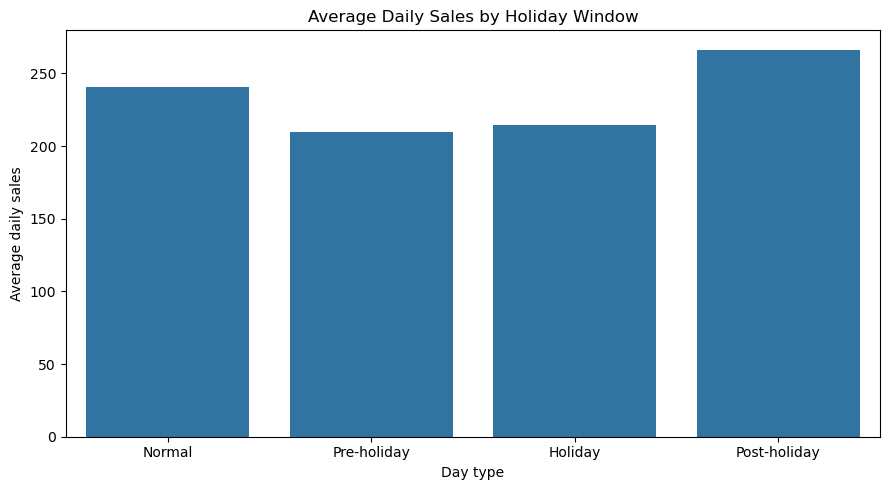

In [28]:
window_order = ["Normal", "Pre-holiday", "Holiday", "Post-holiday"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=holiday_window_summary,
    x="holiday_window",
    y="average_daily_sales",
    order=window_order
)

plt.title("Average Daily Sales by Holiday Window")
plt.xlabel("Day type")
plt.ylabel("Average daily sales")
plt.tight_layout()
plt.show()

In [29]:
country_window_summary = (
    daily
    .groupby(["country", "holiday_window"])
    .agg(
        days=("date", "count"),
        average_daily_sales=("daily_sales", "mean"),
        median_daily_sales=("daily_sales", "median"),
        share_of_days_with_sales=("has_sales", "mean")
    )
    .reset_index()
)

display(country_window_summary.head(40))

,country,holiday_window,days,average_daily_sales,median_daily_sales,share_of_days_with_sales
0,Austria,Holiday,50,21.840000,0.0,0.040000
1,Austria,Normal,1137,71.110818,0.0,0.121372
2,Austria,Post-holiday,121,41.198347,0.0,0.082645
3,Austria,Pre-holiday,138,40.673913,0.0,0.123188
4,Belgium,Holiday,39,44.461538,0.0,0.076923
5,Belgium,Normal,1165,34.495279,0.0,0.049785
6,Belgium,Post-holiday,113,41.884956,0.0,0.026549
7,Belgium,Pre-holiday,117,22.042735,0.0,0.042735
8,France,Holiday,43,460.000000,168.0,0.581395
9,France,Normal,1164,606.599656,64.0,0.542955


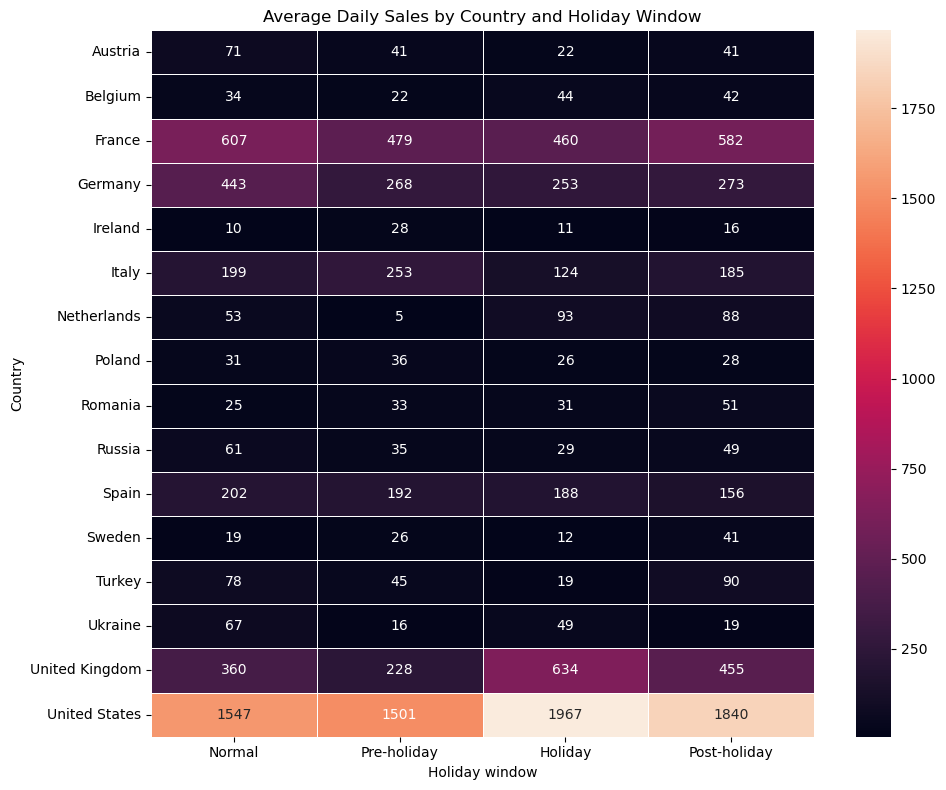

In [30]:
pivot_avg_sales = (
    country_window_summary
    .pivot(index="country", columns="holiday_window", values="average_daily_sales")
    .reindex(columns=window_order)
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_avg_sales,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Average Daily Sales by Country and Holiday Window")
plt.xlabel("Holiday window")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The heatmap shows that holiday patterns differ across countries. For example, the United States has much higher average sales than most other countries in all holiday windows. This confirms that country-level differences are large and should be controlled for in the regression analysis.

## 7. Statistical and Regression Analysis

A Welch t-test is first used as a simple comparison between holiday and non-holiday sales. This test checks whether average daily sales differ between the two groups without assuming equal variance.

The t-test is only a preliminary test because it does not control for country differences or calendar effects. Therefore, the main analysis uses an OLS regression model with log daily sales as the dependent variable. The model includes controls for country, year, month, and weekday. These controls are important because sales levels differ across countries and may also vary systematically across time.

The regression coefficients for `pre_holiday_3days`, `is_holiday`, and `post_holiday_3days` show whether sales differ from normal days after controlling for these factors. Since the dependent variable is log daily sales, the coefficients are converted into approximate percentage effects using `exp(coefficient) - 1`.

In [31]:
holiday_sales = daily.loc[daily["is_holiday"] == 1, "daily_sales"]
nonholiday_sales = daily.loc[daily["is_holiday"] == 0, "daily_sales"]

t_stat, p_value = stats.ttest_ind(
    holiday_sales,
    nonholiday_sales,
    equal_var=False,
    nan_policy="omit"
)

print("Mean sales on holidays:", holiday_sales.mean())
print("Mean sales on non-holidays:", nonholiday_sales.mean())
print("Welch t-statistic:", t_stat)
print("p-value:", p_value)

Mean sales on holidays: 214.39657853810263
Mean sales on non-holidays: 240.34571045576408
Welch t-statistic: -0.824186499361138
p-value: 0.4101205960487938


The t-test shows that average sales are slightly higher on holidays than on non-holidays. However, the p-value is high, meaning that the difference is not statistically significant. Therefore, the simple comparison does not provide strong evidence that holiday sales are different from non-holiday sales.

Because this test does not control for country or calendar effects, I next use a regression model.

### Main regression model

The main regression model uses log daily sales as the dependent variable. The main explanatory variables are `pre_holiday_3days`, `is_holiday`, and `post_holiday_3days`.

The model also controls for country, year, month, and weekday effects. These controls are important because sales levels differ strongly between countries and may also vary depending on the time of year or day of the week.

In [32]:
model = smf.ols(
    formula="""
        log_daily_sales ~ pre_holiday_3days + is_holiday + post_holiday_3days
        + C(country) + C(year) + C(month) + C(weekday)
    """,
    data=daily
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_daily_sales   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     378.4
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        14:41:04   Log-Likelihood:                -50060.
No. Observations:               23023   AIC:                         1.002e+05
Df Residuals:                   22984   BIC:                         1.005e+05
Df Model:                          38                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

The full regression table contains many control variables, so I focus the interpretation on the three holiday-window variables. Since the dependent variable is log daily sales, the coefficients are converted into approximate percentage effects using `exp(coefficient) - 1`.

In [33]:
effect_vars = ["pre_holiday_3days", "is_holiday", "post_holiday_3days"]

regression_effects = pd.DataFrame({
    "coefficient": model.params,
    "p_value": model.pvalues
}).loc[effect_vars]

regression_effects["approx_percent_effect"] = (
    np.exp(regression_effects["coefficient"]) - 1
) * 100

display(regression_effects)

,coefficient,p_value,approx_percent_effect
pre_holiday_3days,-0.087287,0.103586,-8.358627
is_holiday,-0.022395,0.782187,-2.214564
post_holiday_3days,0.026559,0.627934,2.691522


The main regression results do not show a statistically significant holiday effect. The coefficient for `is_holiday` is positive, but very small and clearly insignificant. The post-holiday coefficient is also close to zero and statistically insignificant.

The pre-holiday coefficient is negative and close to significance, suggesting that sales may be somewhat lower in the three days before a holiday. However, the p-value is slightly above the conventional 5% threshold, so this should be interpreted carefully rather than as strong evidence.

Overall, the main regression suggests that national holidays themselves are not strongly associated with changes in daily sales once country, year, month, and weekday effects are controlled for.

### Robustness check: active sales days only

The main model includes the complete country-date panel, meaning that dates without transactions are treated as zero-sales days. This is useful because holidays with no sales should not be dropped automatically.

However, the Superstore dataset is a sample dataset, so zero-sales days may not always represent true zero demand. Therefore, I run a robustness check using only days with positive sales. This checks whether the results depend on how zero-sales days are treated.

In [34]:
active_daily = daily[daily["daily_sales"] > 0].copy()

active_model = smf.ols(
    formula="""
        log_daily_sales ~ pre_holiday_3days + is_holiday + post_holiday_3days
        + C(country) + C(year) + C(month) + C(weekday)
    """,
    data=active_daily
).fit(cov_type="HC1")

print(active_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_daily_sales   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     41.21
Date:                Sun, 10 May 2026   Prob (F-statistic):          1.09e-266
Time:                        14:41:04   Log-Likelihood:                -9949.2
No. Observations:                5727   AIC:                         1.998e+04
Df Residuals:                    5688   BIC:                         2.024e+04
Df Model:                          38                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [35]:
active_regression_effects = pd.DataFrame({
    "coefficient": active_model.params,
    "p_value": active_model.pvalues
}).loc[effect_vars]

active_regression_effects["approx_percent_effect"] = (
    np.exp(active_regression_effects["coefficient"]) - 1
) * 100

display(active_regression_effects)

,coefficient,p_value,approx_percent_effect
pre_holiday_3days,-0.047940,0.515527,-4.680888
is_holiday,-0.042249,0.696647,-4.136877
post_holiday_3days,-0.046453,0.540904,-4.539104


The robustness check supports the main conclusion. When only active sales days are included, the pre-holiday, holiday, and post-holiday coefficients are all statistically insignificant. This means that there is no strong evidence of a systematic national holiday effect after removing zero-sales days.

The result also shows that the borderline pre-holiday effect from the full-panel model is not robust. Therefore, the safest conclusion is that national holidays do not appear to be a strong standalone driver of daily sales in this dataset.

In [36]:
table_1_country_coverage = final_country_coverage[
    ["country", "number_of_rows", "distinct_sales_days", "first_order_date", "last_order_date", "total_sales"]
].copy()

table_2_holiday_window_summary = holiday_window_summary.copy()

table_3_regression_effects = regression_effects.reset_index().rename(
    columns={"index": "variable"}
)

table_4_active_sales_regression_effects = active_regression_effects.reset_index().rename(
    columns={"index": "variable"}
)

display(table_1_country_coverage)
display(table_2_holiday_window_summary)
display(table_3_regression_effects)
display(table_4_active_sales_regression_effects)

,country,number_of_rows,distinct_sales_days,first_order_date,last_order_date,total_sales
0,United States,9994,1238,2011-01-04,2014-12-31,2297354
2,France,2827,789,2011-01-04,2014-12-31,858930
4,Germany,2065,652,2011-01-12,2014-12-31,628857
6,United Kingdom,1633,604,2011-01-03,2014-12-31,528570
10,Turkey,1378,494,2011-01-11,2014-12-31,108524
11,Italy,1108,437,2011-01-11,2014-12-30,289717
13,Spain,859,366,2011-01-11,2014-12-31,287162
26,Netherlands,435,192,2011-01-07,2014-12-31,77520
31,Russia,384,173,2011-01-20,2014-12-31,82915
32,Ukraine,381,194,2011-03-01,2014-12-31,86855


,holiday_window,days,total_sales,average_daily_sales,median_daily_sales,average_orders,average_units_sold,share_of_days_with_sales
0,Holiday,643,137857.0,214.396579,0.0,0.500778,3.457232,0.225505
1,Normal,19495,4696157.0,240.890331,0.0,0.488433,3.476481,0.250526
2,Post-holiday,1380,367540.0,266.333333,0.0,0.552899,4.072464,0.263768
3,Pre-holiday,1505,315240.0,209.461794,0.0,0.447176,3.145515,0.221927


,variable,coefficient,p_value,approx_percent_effect
0,pre_holiday_3days,-0.087287,0.103586,-8.358627
1,is_holiday,-0.022395,0.782187,-2.214564
2,post_holiday_3days,0.026559,0.627934,2.691522


,variable,coefficient,p_value,approx_percent_effect
0,pre_holiday_3days,-0.047940,0.515527,-4.680888
1,is_holiday,-0.042249,0.696647,-4.136877
2,post_holiday_3days,-0.046453,0.540904,-4.539104


In [37]:
table_1_country_coverage.to_csv("table_1_country_coverage.csv", index=False)
table_2_holiday_window_summary.to_csv("table_2_holiday_window_summary.csv", index=False)
table_3_regression_effects.to_csv("table_3_regression_effects.csv", index=False)
table_4_active_sales_regression_effects.to_csv("table_4_active_sales_regression_effects.csv", index=False)

daily.to_csv("final_daily_superstore_holiday_dataset.csv", index=False)

print("Tables and final daily dataset exported.")

Tables and final daily dataset exported.


## 8. Conclusion, Limitations, and Business Insights

This project combined Superstore transaction data with external national holiday data from the Calendarific API. The analysis creates a daily country-level dataset and compares sales on normal days, national holidays, and the days before and after national holidays.

The descriptive results show some differences between holiday windows. Average daily sales are highest after holidays and lowest before holidays. However, the statistical tests do not provide strong evidence of a national holiday effect. The t-test is insignificant, and the regression results show that the holiday and post-holiday coefficients are very small and statistically insignificant. The pre-holiday effect is negative in the full-panel model, but it is only borderline significant and disappears in the active-sales-days robustness check.

The main business insight is therefore that national holidays alone do not appear to be a strong standalone driver of daily sales in this dataset. However, holiday indicators are still useful calendar features. They help structure the analysis and could be useful in a larger forecasting model together with other variables such as promotions.

There are also some limitations. The Superstore dataset is a sample dataset, so zero-sales days may not always represent true zero demand. Second, the analysis is based on country-level holiday dates, even though shopping behavior may differ by region, customer segment, or product category. Third, the model identifies associations rather than causal effects. Other factors, such as promotions or seasonal shopping patterns, may overlap with holidays.

Overall, I find that the project shows how external API data can be integrated with transaction data to create useful business intelligence features and evaluate holiday-related sales patterns.